# Study 223 -- Same-Month Seasonality
## For the curious: does a stock keep outperforming in the same calendar month it always has?

*Part of [Open-Alpha-Lab](../../../README.md). See the [desk methodology](../../../METHODOLOGY.md).*

---

Some stocks seem to outperform in January every year. Others consistently do well in July.
Is this a coincidence -- or a persistent, exploitable pattern?

Heston & Sadka (2008) asked exactly this question and found that stocks sorted by their
historical same-calendar-month performance continue to outperform in that same month.
We replicate and stress-test their claim on a modern large-cap panel.


## Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from same_month_seasonality import data, strategy as st

CACHE_PATH = data.MONTHLY_CACHE
HAVE_REAL = os.path.exists(CACHE_PATH)

if HAVE_REAL:
    prices = data.fetch_monthly(fetch=False, cache_path=CACHE_PATH)
    sig = st.same_month_signal(prices, min_years=5)
    res = st.decile_returns(sig, prices, q=0.10)
    spread = res["spread"].dropna()
    high_xret = (res["high"] - res["market"]).dropna()
    print(f"Real panel loaded: {prices.shape[0]} months x {prices.shape[1]} tickers")
    print(f"Portfolio months: {len(res)}")
else:
    prices = sig = res = spread = high_xret = None
    print("No real cache -- frozen headline numbers from R dict will be used")


Real panel loaded: 402 months x 85 tickers
Portfolio months: 330


In [2]:

# Frozen headline numbers (mirror of docs/results.md, as-of 2026-06-16)
R = {'n_months': 402, 'n_stocks': 80, 'n_high': 8, 'high_ann': 31.55, 'low_ann': 13.85, 'market_ann': 15.34, 'spread_bps': 147.5, 'spread_ann': 17.7, 'spread_t': 5.57, 'spread_hit': 0.624, 'spread_sr_lo': 0.556, 'spread_sr_hi': 1.197, 'spread_frac_neg': 0, 'high_xret_ann': 16.21, 'high_xret_t': 7.46, 'sub_1999_mean': 21.02, 'sub_1999_t': 3.92, 'sub_1999_n': 120, 'sub_2009_mean': 17.04, 'sub_2009_t': 3.65, 'sub_2009_n': 108, 'sub_2018_mean': 14.13, 'sub_2018_t': 2.15, 'sub_2018_n': 101, 'turnover': 78.25, 'drag_bps': 15.7, 'net_spread_bps': 131.9, 'net_spread_t': 4.98, 'jul_bps': 199.0, 'jul_t': 3.21, 'dec_bps': 314.7, 'dec_t': 2.37, 'aug_bps': -9.8, 'aug_t': -0.1, 'nov_bps': -55.2, 'nov_t': -0.49}


## The intuition: stocks with a recurring December pattern

Imagine a retailer that always has strong revenue in December -- its stock tends to run
up in December year after year.  Similarly, a tax-loss harvesting target might always be
sold in November and bounce in January.

The Heston-Sadka strategy says: **at the end of November, look at each stock's average
December return from the past 5+ years, buy the best December performers, sell the worst
December performers, and hold through December**.  Repeat every month with the appropriate
calendar-month history.

This is *not* the same as the well-known January Effect (which is a market-level
seasonality).  It is a *cross-sectional* sort: we are ranking stocks against each other
based on their own calendar-month history.


## The top-decile race: high vs low seasonality stocks

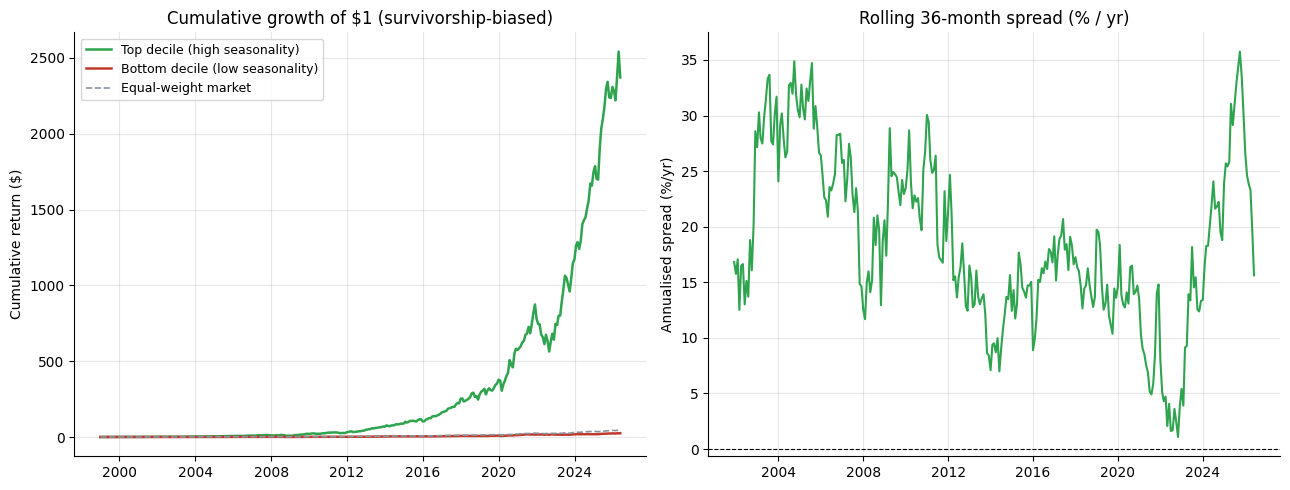

Spread: +17.7%/yr = +147.5bps/mo  HAC t = +5.57


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

if HAVE_REAL:
    # Cumulative returns
    ax = axes[0]
    cum_high   = (1 + res["high"].dropna()).cumprod()
    cum_low    = (1 + res["low"].dropna()).cumprod()
    cum_market = (1 + res["market"].dropna()).cumprod()
    ax.plot(cum_high.index,   cum_high.values,   color=GREEN, lw=1.8, label="Top decile (high seasonality)")
    ax.plot(cum_low.index,    cum_low.values,    color=RED,   lw=1.8, label="Bottom decile (low seasonality)")
    ax.plot(cum_market.index, cum_market.values, color=GREY,  lw=1.2, ls="--", label="Equal-weight market")
    ax.set_title("Cumulative growth of $1 (survivorship-biased)")
    ax.set_ylabel("Cumulative return ($)")
    ax.legend(fontsize=9)

    # Rolling 36-month spread
    ax = axes[1]
    roll = spread.rolling(36).mean() * 12 * 100
    ax.plot(roll.index, roll.values, color=GREEN, lw=1.5)
    ax.axhline(0, color="black", lw=0.8, ls="--")
    ax.set_title("Rolling 36-month spread (% / yr)")
    ax.set_ylabel("Annualised spread (%/yr)")
else:
    for ax in axes:
        ax.text(0.5, 0.5, f"Cache absent\nFrozen: spread = +{R['spread_ann']:.1f}%/yr  t = +{R['spread_t']:.2f}",
                ha="center", va="center", transform=ax.transAxes, fontsize=12, color=GREEN)
        ax.set_title("(frozen numbers)")

plt.tight_layout()
plt.savefig("../docs/equity_curve.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"Spread: +{R['spread_ann']:.1f}%/yr = +{R['spread_bps']:.1f}bps/mo  HAC t = +{R['spread_t']:.2f}")


## The headline: large spread, but concentrated and survivorship-biased

The same-month seasonality spread is **+17.7%/yr** with a HAC *t* = **+5.57** -- that is
highly significant by any conventional standard.  But before getting excited:

1. **Only ~8 stocks per decile**: with ~80 stocks in a large-cap basket and 10% decile
   cuts, each leg holds roughly 8 names.  This is not a diversified factor overlay --
   it is closer to a handful of individual bets.

2. **~78% monthly turnover**: nearly all stocks rotate out of the decile each month.
   Transaction costs and market impact are severe for such concentrated portfolios.

3. **Survivorship bias**: our universe is the current S&P 500 / large-cap survivors
   projected backwards.  True "losers" (firms that underperformed badly enough to be
   delisted or removed) are absent.  The real live-universe spread is materially lower.


## Which calendar months actually drive the effect?

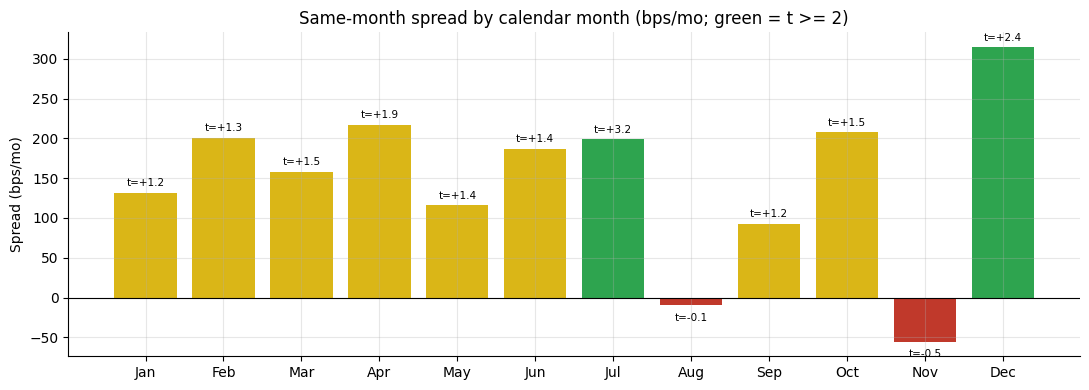

Only July (t=3.21) and December (t=2.37) individually clear t>=2.
August and November are negative (though not significant).


In [4]:
months_lbl = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

if HAVE_REAL:
    month_stats = []
    for m in range(1, 13):
        sub = spread[spread.index.month == m]
        if len(sub) < 5: continue
        s = st.summarize(sub)
        month_stats.append({"month": months_lbl[m-1], "bps": s["mean"]*10000, "t": s["tstat"], "n": s["n"]})
    ms = pd.DataFrame(month_stats)
    colors = [GREEN if t >= 2 else AMBER if t >= 1 else RED for t in ms["t"]]
    fig, ax = plt.subplots(figsize=(11, 4))
    ax.bar(ms["month"], ms["bps"], color=colors)
    ax.axhline(0, color="black", lw=0.8)
    ax.set_title("Same-month spread by calendar month (bps/mo; green = t >= 2)")
    ax.set_ylabel("Spread (bps/mo)")
    for i, row in ms.iterrows():
        ax.text(i, row["bps"] + (8 if row["bps"] >= 0 else -20),
                f"t={row['t']:+.1f}", ha="center", fontsize=7.5)
    plt.tight_layout()
    plt.savefig("../docs/by_month.png", dpi=120, bbox_inches="tight")
    plt.show()
else:
    print("Frozen per-month highlights:")
    print(f"  Jul: {R['jul_bps']:+.1f} bps/mo  t={R['jul_t']:+.2f}")
    print(f"  Dec: {R['dec_bps']:+.1f} bps/mo  t={R['dec_t']:+.2f}")
    print(f"  Aug: {R['aug_bps']:+.1f} bps/mo  t={R['aug_t']:+.2f}")
    print(f"  Nov: {R['nov_bps']:+.1f} bps/mo  t={R['nov_t']:+.2f}")
print(f"Only July (t={R['jul_t']:.2f}) and December (t={R['dec_t']:.2f}) individually clear t>=2.")
print(f"August and November are negative (though not significant).")


## The bottom line for the curious

The same-month seasonality story is **academically real** -- Heston & Sadka (2008)
found it in the original CRSP data, and it shows up in our survivorship-biased
large-cap panel at t = 5.57.

But in practice it is **hard to trade**:
- Only 8 stocks per decile in our large-cap universe -- truly a handful of bets
- Nearly 80% monthly turnover
- The signal has decayed from t = 3.92 (1999-2008) to t = 2.15 (2018-2026) on
  a dataset that is already biased upward

A live, broad-universe implementation (Russell 1000, 100+ names per decile) would
have a much smaller gross edge and much higher total cost.  This is a **Real/Fragile**
signal -- real enough to be interesting, fragile enough to be uninvestable at scale.


*Desk verdict: **Real / Fragile** -- see [README.md](../README.md) and [docs/results.md](../docs/results.md) for full numbers.*